In [1]:
import os
import sys
from pathlib import Path

if os.getcwd().endswith("scripts"):
    os.chdir("..")
sys.path.insert(0, "src")

import yaml
import torch

from utils import resolve_device, set_seed, plot_history
from data import get_loaders
from models import PlainCNN
from trainer import train, evaluate



In [2]:
config_path = "configs.yaml"
with open(config_path, "r") as f:   
    cfg = yaml.safe_load(f)

device = resolve_device(cfg["device"])
print(f"Device: {device}")

SEED = cfg.get("seed", 42)
set_seed(SEED)
print(f"Random seed set to: {SEED}")


Device: xpu
Random seed set to: 42


In [3]:
train_loader, val_loader, test_loader = get_loaders(
    data_dir="data",
    batch_size=cfg["data"]["batch_size"],
    num_workers=cfg["data"]["num_workers"],
    augment=cfg["train"]["augment"],
    val_split_seed=cfg["train"]["val_split_seed"]
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


Number of training batches: 704
Number of validation batches: 79
Number of testing batches: 157


In [4]:
plain_cnn = PlainCNN(num_classes=cfg["model"]["num_classes"]).to(device)
plain_cnn_optimizer = torch.optim.Adam(plain_cnn.parameters(), lr=1e-3)

criterion = torch.nn.CrossEntropyLoss()

print(plain_cnn)
print(f"Number of parameters: {sum(p.numel() for p in plain_cnn.parameters()):,}")

PlainCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128

[22:36:26] Epoch 01/30
Train: [1.2196, 0.5614] | Val: [1.1021, 0.6024] | 18.12s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.6024

[22:36:45] Epoch 02/30
Train: [0.8487, 0.7004] | Val: [0.9578, 0.6782] | 16.22s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.6782

[22:37:01] Epoch 03/30
Train: [0.6793, 0.7640] | Val: [0.8372, 0.7076] | 16.15s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.7076

[22:37:17] Epoch 04/30
Train: [0.5757, 0.7989] | Val: [0.7266, 0.7404] | 16.06s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.7404

[22:37:33] Epoch 05/30
Train: [0.5021, 0.8277] | Val: [0.9142, 0.7134] | 16.11s

[22:37:49] Epoch 06/30
Train: [0.4416, 0.8462] | Val: [0.5978, 0.8026] | 16.03s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.8026

[22:38:05] Epoch 07/30
Train: [0.3940, 0.8638] | Val: [0.5892, 0.8024] | 16.03s

[22:38:21] Epoch 08/30
Train: [0.3482, 0.8796] | Val: [0.7

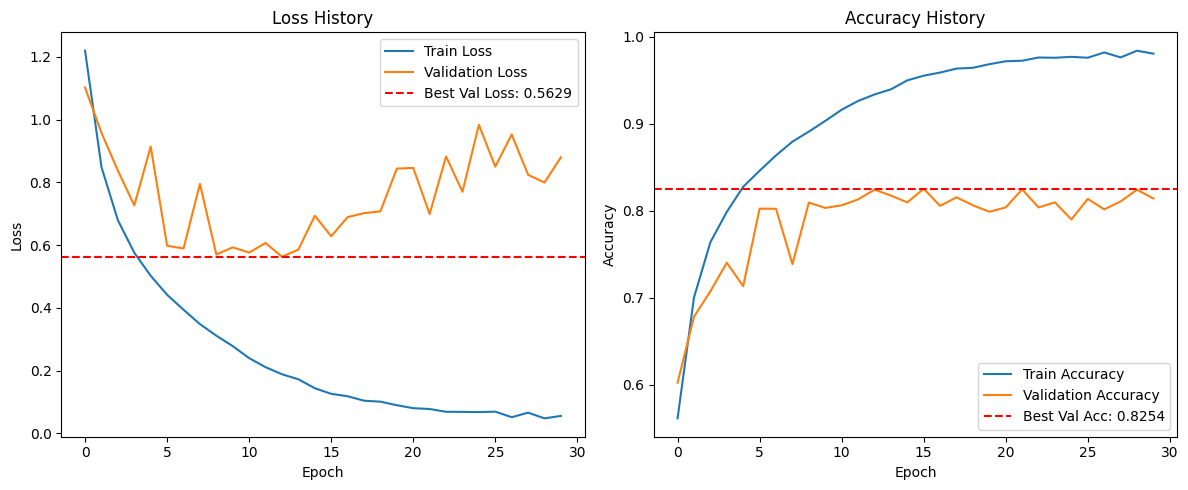

In [5]:
epochs = cfg.get("train", {}).get("epochs", 10)
ckpt_dir = cfg.get("train", {}).get("checkpoint_dir", "checkpoints")
ckpt_dir = Path(ckpt_dir)

history = train(
    model=plain_cnn,
    optimizer=plain_cnn_optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    ckpt_dir=ckpt_dir,
    save_name="best_plain_cnn.pt"
)

plot_history(history, save_path=ckpt_dir / "history_plain_cnn.png", show=True)


In [6]:
print(f"Loading best model for testing from {ckpt_dir / 'best_plain_cnn.pt'}")
plain_cnn.load_state_dict(torch.load(ckpt_dir / "best_plain_cnn.pt"))

test_loss, test_acc = evaluate(plain_cnn, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Loading best model for testing from checkpoints\best_plain_cnn.pt
Test Loss: 0.6445 | Test Acc: 0.8261
